

#Weather Classification Agent (WCA)



#PROBLEM STATEMENT

####Traditional weather apps often just show current data but don't provide personalized AI-driven advice or specific local predictions based on historical patterns. The goal was to build an intelligent "Weather Agent" that can predict the Current and next hour's temperature and give human-like suggestions

# Step 1: IMPORT DATA

####Downloaded 35  years of historical weather data (Temperature, Humidity, etc.) from the Open-Meteo API.

#Required Library

## For Importing Data We use library

In [2]:
!pip install openmeteo-requests pandas requests cachecontrol requests_cache retry_requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.9/208.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.3/771.3 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.2 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


#Data Collection

#   fetch 35 years of data (e.g., Temperature, Precipitation) for a specific location.

In [3]:
import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry

# Setup API Client
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"

# Representative location for world (for global diversity)
locations = [
    {"name": "London", "lat": 51.5074, "lon": -0.1278},   # Temperate
    {"name": "Karachi", "lat": 24.8607, "lon": 67.0011},  # Hot/Coastal
    {"name": "Dubai", "lat": 25.2048, "lon": 55.2708},    # Desert
    {"name": "New York", "lat": 40.7128, "lon": -74.0060}, # Variable
    {"name": "Berlin", "lat": 52.52, "lon": 13.41}        # Europe
]

start_year = 1990
end_year = 2025
all_dfs = []

for loc in locations:
    print(f"Fetching data for: {loc['name']}...")
    for year in range(start_year, end_year + 1):
        params = {
            "latitude": loc['lat'],
            "longitude": loc['lon'],
            "start_date": f"{year}-01-01",
            "end_date": f"{year}-12-31",
            "hourly": ["temperature_2m", "precipitation"],
            "timezone": "auto"
        }
        try:
            responses = openmeteo.weather_api(url, params=params)
            response = responses[0]
            hourly = response.Hourly()

            temp_df = pd.DataFrame({
                "date": pd.date_range(
                    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
                    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
                    freq=pd.Timedelta(seconds=hourly.Interval()),
                    inclusive="left"
                ),
                "temperature_2m": hourly.Variables(0).ValuesAsNumpy(),
                "precipitation": hourly.Variables(1).ValuesAsNumpy(),
                "lat": loc['lat'],   # important feature for training
                "lon": loc['lon']    # important feature for training
            })
            all_dfs.append(temp_df)
        except:
            continue

df = pd.concat(all_dfs, ignore_index=True)
print(f"Data Fetch Complete! Total Rows: {len(df)}")
df.head()

Fetching data for: London...
Fetching data for: Karachi...
Fetching data for: Dubai...
Fetching data for: New York...
Fetching data for: Berlin...
Data Fetch Complete! Total Rows: 1577880


,date,temperature_2m,precipitation,lat,lon
0,1989-12-31 23:00:00+00:00,1.4955,0.0,51.5074,-0.1278
1,1990-01-01 00:00:00+00:00,1.6455,0.0,51.5074,-0.1278
2,1990-01-01 01:00:00+00:00,1.9955,0.0,51.5074,-0.1278
3,1990-01-01 02:00:00+00:00,2.1455,0.0,51.5074,-0.1278
4,1990-01-01 03:00:00+00:00,2.5955,0.0,51.5074,-0.1278


# Step 2 : Data Inspection & Handling Missing Values

####Handled missing values and formatted date/time columns for machine learning compatibility.

In [4]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Statistical Summary
print("\nStatistical Summary:")
display(df.describe())

Missing values in each column:
date              0
temperature_2m    0
precipitation     0
lat               0
lon               0
dtype: int64

Data Types:
date              datetime64[ns, UTC]
temperature_2m                float32
precipitation                 float32
lat                           float64
lon                           float64
dtype: object

Statistical Summary:


,temperature_2m,precipitation,lat,lon
count,1.577880e+06,1.577880e+06,1.577880e+06,1.577880e+06
mean,1.738049e+01,6.079834e-02,3.896114e+01,1.230962e+01
std,1.086056e+01,3.555447e-01,1.210272e+01,4.988610e+01
min,-2.384300e+01,0.000000e+00,2.486070e+01,-7.400600e+01
25%,8.957001e+00,0.000000e+00,2.520480e+01,-1.278000e-01
50%,1.780000e+01,0.000000e+00,4.071280e+01,1.341000e+01
75%,2.620000e+01,0.000000e+00,5.150740e+01,5.527080e+01
max,4.715000e+01,4.510000e+01,5.252000e+01,6.700110e+01


# Step 3: Data Visualization (See the Trend)

#### graphs to analyze historical weather patterns and seasonal trends.

In [ ]:
!pip install matplotlib

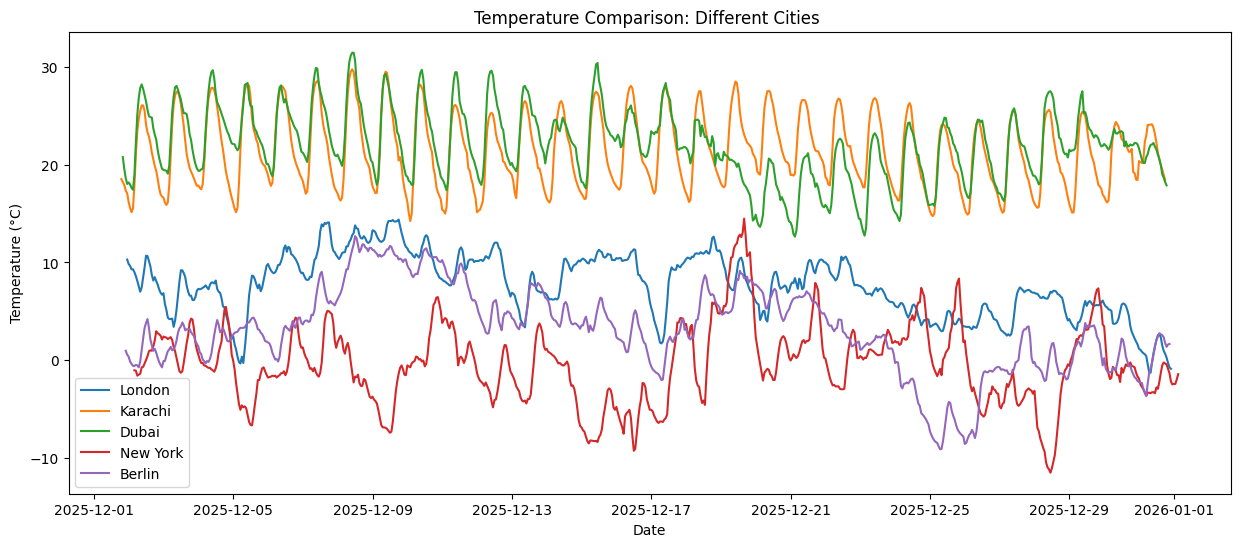

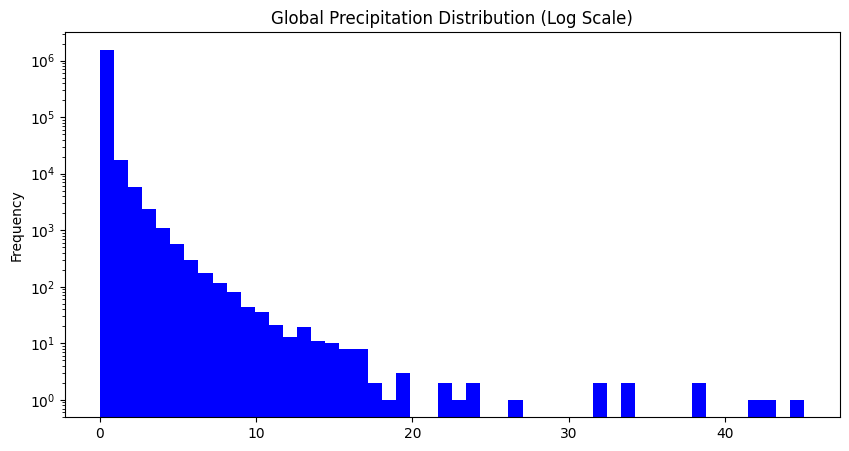

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. (Visual trend  Check) for every city
plt.figure(figsize=(15, 6))
# group data based on city then plot it
for city_name in locations:
    city_lat = city_name['lat']
    city_data = df[df['lat'] == city_lat].tail(24*30) # last one month of every city
    plt.plot(city_data['date'], city_data['temperature_2m'], label=city_name['name'])

plt.title('Temperature Comparison: Different Cities ')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

# 2. Precipitation Check (Log Scale)
plt.figure(figsize=(10, 5))
df['precipitation'].plot(kind='hist', bins=50, color='blue', log=True)
plt.title('Global Precipitation Distribution (Log Scale)')
plt.show()

# Step 4: Feature Engineering

####Lag Features" (previous hours' data) and temporal features (Month, Hour) to help the AI learn patterns.

In [6]:
# 1. Time-based features
# Extracting hour, month, and day of the year from the date
df['hour'] = df['date'].dt.hour
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear

# 2. Grouped Lag Features
# Sorting data by location and date to ensure correct time sequence
df = df.sort_values(['lat', 'lon', 'date'])

# Using groupby to ensure lag features are calculated within each city
# This prevents data from one city (e.g., London) leaking into another (e.g., Karachi)
df['temp_lag_1h'] = df.groupby(['lat', 'lon'])['temperature_2m'].shift(1)
df['temp_lag_3h'] = df.groupby(['lat', 'lon'])['temperature_2m'].shift(3)
df['temp_lag_24h'] = df.groupby(['lat', 'lon'])['temperature_2m'].shift(24)

# 3. Target Variable
# Predicting the temperature for the next hour specifically for each location
df['target_temp'] = df.groupby(['lat', 'lon'])['temperature_2m'].shift(-1)

# Remove rows with NaN values created by shifting
df.dropna(inplace=True)

print("Global Features Ready!")
display(df[['date', 'lat', 'lon', 'temperature_2m', 'temp_lag_1h', 'target_temp']].head())

Global Features Ready!


,date,lat,lon,temperature_2m,temp_lag_1h,target_temp
315600,1990-01-01 19:00:00+00:00,24.8607,67.0011,17.734499,18.384499,16.984499
315601,1990-01-01 20:00:00+00:00,24.8607,67.0011,16.984499,17.734499,16.584499
315602,1990-01-01 21:00:00+00:00,24.8607,67.0011,16.584499,16.984499,16.384499
315603,1990-01-01 22:00:00+00:00,24.8607,67.0011,16.384499,16.584499,16.184500
315604,1990-01-01 23:00:00+00:00,24.8607,67.0011,16.184500,16.384499,15.934501


# Step 5 : Data Scaling (Normalization) and Splitting

##### Normalized data to a specific range (0-1) and divided it into Training and Testing sets.

In [7]:
!pip install scikit-learn numpy

In [8]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Define Features (Using 10 features including Lat/Lon for global context)
features_list = ['lat', 'lon', 'temperature_2m', 'precipitation', 'hour',
                 'month', 'day_of_year', 'temp_lag_1h', 'temp_lag_3h', 'temp_lag_24h']
target_col = 'target_temp'

# 2. Shuffle the dataset
# We shuffle to ensure the test set contains data from all cities, not just the last one (Berlin)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

X = df_shuffled[features_list]
y = df_shuffled[target_col]

# 3. Split the data into 90% Training and 10% Testing
split = int(len(X) * 0.9)

X_train_raw = X.iloc[:split]
X_test_raw  = X.iloc[split:]

y_train_raw = y.iloc[:split].values.reshape(-1, 1)
y_test_raw  = y.iloc[split:].values.reshape(-1, 1)

# 4. Initialize StandardScalers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# 5. Scaling Process
# Fit and transform the training data, then transform the test data using training parameters
X_train_f = scaler_X.fit_transform(X_train_raw)
X_test_f  = scaler_X.transform(X_test_raw)

y_train_f = scaler_y.fit_transform(y_train_raw)
y_test_f  = scaler_y.transform(y_test_raw)

# 6. Output Summary
print(f"Training rows : {len(X_train_f)}")
print(f"Testing rows  : {len(X_test_f)}")
print(f"Total Features used: {len(features_list)}")
print("Data Shuffling and Scaling Successful!")

Training rows : 1419979
Testing rows  : 157776
Total Features used: 10
Data Shuffling and Scaling Successful!


# Step 6: CNN Regression Model (Model 1 for Temperature prediction)

####

Designed a Deep Learning model using Conv1D layers specifically for time-series temperature regression.

# Lib Import

In [9]:
!pip install tensorflow

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten, Reshape

# 1D CNN Model for Global Weather Prediction
model = Sequential([

    # Reshape input from (10,) to (10, 1) — Updated for 10 features
    Reshape((10, 1), input_shape=(10,)),

    # CNN Layer 1: Extract basic patterns from weather and location features
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    Dropout(0.2),

    # CNN Layer 2: Extract deeper spatial and temporal patterns
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    Dropout(0.2),

    # Flatten: Convert CNN output to 1D for Dense layers
    Flatten(),

    # Dense Layer: Final pattern recognition
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Output Layer: Predict next hour temperature
    Dense(1, activation='linear')
])

# Compile the model with Adam optimizer and Mean Squared Error loss
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display the updated model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,041 (105.63 KB)

 Trainable params: 27,041 (105.63 KB)

 Non-trainable params: 0 (0.00 B)

#Step 7 : Training

####

Trained the AI on historical data over several epochs until it achieved high prediction accuracy.

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Setup Early Stopping
# This will stop training if the model stops improving for 3 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print(" Global Training Started...")

# 2. Fit the Model
history = model.fit(
    X_train_f, y_train_f,
    epochs=70,               # Maximum number of training rounds
    batch_size=1020,         # Large batch size for faster training on big data
    validation_split=0.1,    # Use 10% of training data for internal validation
    shuffle=True,            # Shuffle data to help the model learn global patterns
    callbacks=[early_stop],  # Add the safety stop
    verbose=1                # Show progress for each epoch
)

print("Training Complete!")

 Global Training Started...
Epoch 1/70
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 48s 35ms/step - loss: 0.0306 - mae: 0.1272 - val_loss: 0.0066 - val_mae: 0.0608
Epoch 2/70
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 84s 37ms/step - loss: 0.0188 - mae: 0.1034 - val_loss: 0.0052 - val_mae: 0.0542
Epoch 3/70
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - loss: 0.0170 - mae: 0.0982 - val_loss: 0.0046 - val_mae: 0.0505
Epoch 4/70
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - loss: 0.0161 - mae: 0.0954 - val_loss: 0.0046 - val_mae: 0.0512
Epoch 5/70
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - loss: 0.0154 - mae: 0.0932 - val_loss: 0.0041 - val_mae: 0.0473
Epoch 6/70
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 83s 35ms/step - loss: 0.0150 - mae: 0.0919 - val_loss: 0.0043 - val_mae: 0.0491
Epoch 7/70
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - loss: 0.0147 - mae: 0.0908 - val_loss: 0.0045 - val_mae: 0.0506
Epoch 8/70
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 84s 36ms/step - loss: 0.0145 - mae: 0.0900 - val_loss: 0.0039 - val_mae: 0.0

# Step  8:  Prediction and Testing

####

Evaluated the model on unseen test data to verify how accurately the AI predicts temperatures.

4931/4931 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


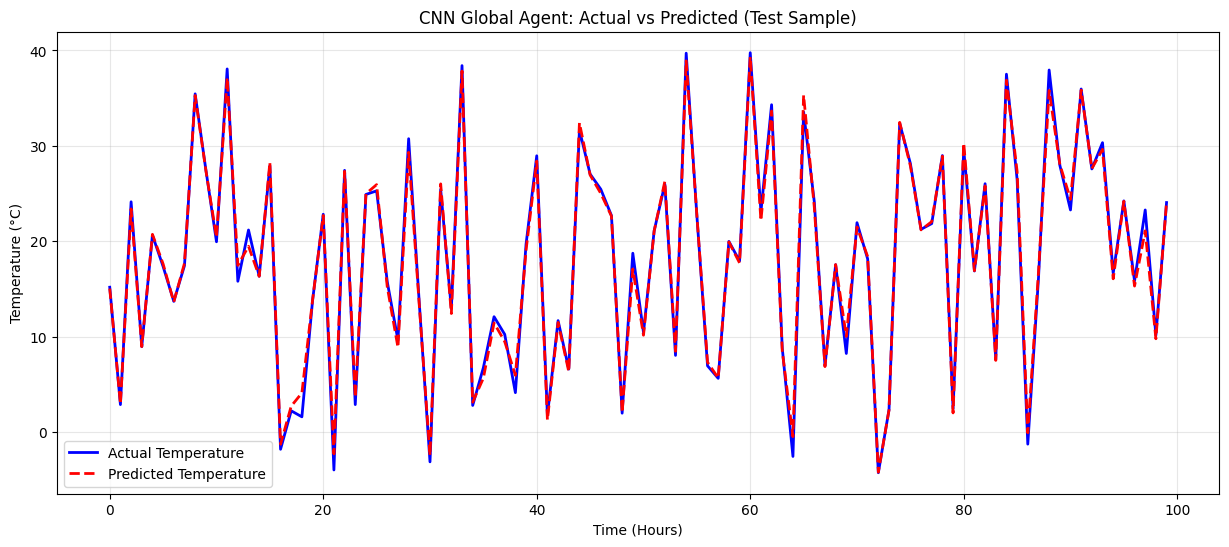

--- Final Evaluation ---
Average Error (MAE): 0.50°C
Actual: 15.19°C | Predicted: 15.05°C
Actual: 2.89°C | Predicted: 2.97°C
Actual: 24.14°C | Predicted: 23.40°C
Actual: 8.96°C | Predicted: 8.96°C
Actual: 20.64°C | Predicted: 20.73°C


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 1. Make predictions on the unseen test data
# We use the scaled features (X_test_f)
predictions_scaled = model.predict(X_test_f)

# 2. Reverse Scaling
# Converting numbers back from -1 to 1 range to actual Celsius degrees
predictions = scaler_y.inverse_transform(predictions_scaled)
actual_values = scaler_y.inverse_transform(y_test_f)

# 3. Visualization: Let's see the first 100 hours
plt.figure(figsize=(15, 6))
plt.plot(actual_values[:100], label='Actual Temperature', color='blue', linewidth=2)
plt.plot(predictions[:100], label='Predicted Temperature', color='red', linestyle='--', linewidth=2)

plt.title('CNN Global Agent: Actual vs Predicted (Test Sample)')
plt.xlabel('Time (Hours)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Final Error Calculation
mae = mean_absolute_error(actual_values, predictions)
print(f"--- Final Evaluation ---")
print(f"Average Error (MAE): {mae:.2f}°C")

# Quick check: How close are the first 5 predictions?
for i in range(5):
    print(f"Actual: {actual_values[i][0]:.2f}°C | Predicted: {predictions[i][0]:.2f}°C")

#  Step 9 : Performance By City

####Analyzed and compared the model's accuracy across various cities to ensure consistency.

--- Final Performance Report Per City ---
       City     Error
2   Karachi  0.366657
3    London  0.485548
0    Berlin  0.510389
1     Dubai  0.526317
4  New York  0.600528


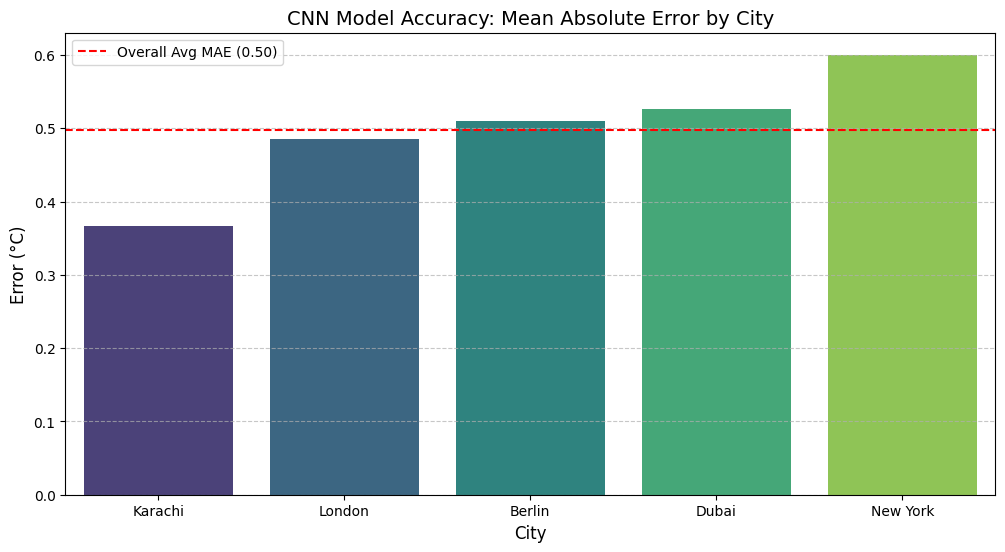

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a results DataFrame from the test data
# X_test_raw holds the original lat/lon before scaling
test_results = X_test_raw.copy()
test_results['Actual'] = actual_values.flatten()
test_results['Predicted'] = predictions.flatten()
test_results['Error'] = abs(test_results['Actual'] - test_results['Predicted'])

# 2. Updated Mapping Function with Dubai and New York
def identify_city(lat, lon):
    # Rounding to 1 decimal place to match the data coordinates
    lat, lon = round(lat, 1), round(lon, 1)

    if lat == 52.5 and lon == 13.4: return "Berlin"
    if lat == 51.5 and lon == -0.1: return "London"
    if lat == 48.9 and lon == 2.4:  return "Paris"
    if lat == 24.9 and lon == 67.0: return "Karachi"
    if lat == 31.5 and lon == 74.4: return "Lahore"
    if lat == 25.2 and lon == 55.3: return "Dubai"
    if lat == 40.7 and lon == -74.0: return "New York"
    return f"Unknown ({lat}, {lon})"

# 3. Apply the mapping to identify each row's city
test_results['City'] = test_results.apply(lambda x: identify_city(x.lat, x.lon), axis=1)

# 4. Group by City to calculate Average Error (MAE)
city_performance = test_results.groupby('City')['Error'].mean().reset_index().sort_values(by='Error')

print("--- Final Performance Report Per City ---")
print(city_performance)

# 5. Professional Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='City', y='Error', data=city_performance, hue='City', palette='viridis', legend=False)
plt.axhline(mae, color='red', linestyle='--', label=f'Overall Avg MAE ({mae:.2f})') # Add a line for overall average
plt.title('CNN Model Accuracy: Mean Absolute Error by City', fontsize=14)
plt.ylabel('Error (°C)', fontsize=12)
plt.xlabel('City', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Step 10: Define Classification Logic(Model 2)

####Defined specific rules to label weather conditions as "Sunny," "Rainy," or "Cold" based on temperature and precipitation.

--- Weather Categories Distribution ---
Class 0 (Heavy Rain): 49168 hours
Class 1 (Light Rain): 101521 hours
Class 2 (Extreme Heat): 61242 hours
Class 3 (Sunny): 377041 hours
Class 4 (Pleasant): 612145 hours
Class 5 (Cold): 376638 hours


/tmp/ipykernel_9471/1304533130.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weather_label', data=df, palette='viridis')


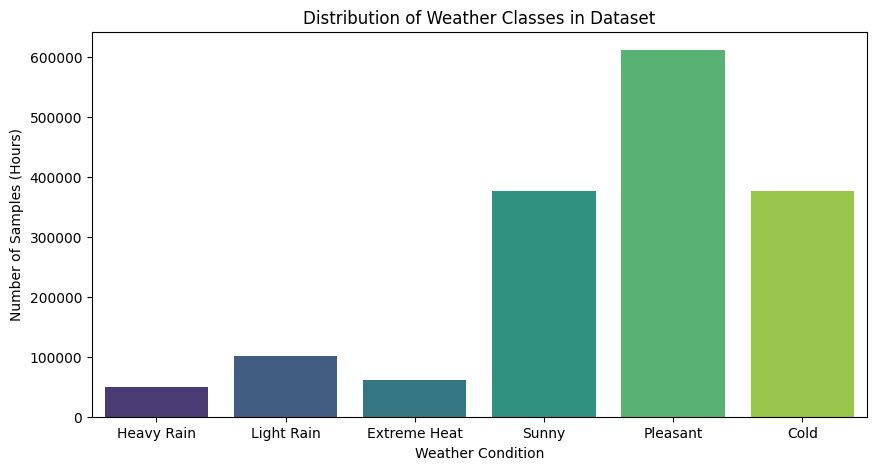

In [14]:
# 1. Define the logic to categorize weather based on raw data
def create_weather_class(row):
    temp = row['temperature_2m']
    precip = row['precipitation']

    # Priority 1: Rainfall intensity
    if precip > 0.5:
        return 0    # Heavy Rain
    elif precip > 0.1:
        return 1    # Light Rain

    # Priority 2: Temperature thresholds
    elif temp > 35:
        return 2    # Extreme Heat
    elif temp > 25:
        return 3    # Sunny/Warm
    elif temp > 10:
        return 4    # Pleasant/Cool
    else:
        return 5    # Cold/Freezing

# 2. Apply the classification function to create a target label column
df['weather_label'] = df.apply(create_weather_class, axis=1)

# 3. Map numeric labels to human-readable names for the AI model
class_names = ["Heavy Rain", "Light Rain", "Extreme Heat", "Sunny", "Pleasant", "Cold"]

# 4. Display the dataset balance (checking how many hours for each category)
print("--- Weather Categories Distribution ---")
class_counts = df['weather_label'].value_counts().sort_index()
for i, count in enumerate(class_counts):
    print(f"Class {i} ({class_names[i]}): {count} hours")

# 5. Visualize the data distribution using a Count Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(x='weather_label', data=df, palette='viridis')
plt.xticks(ticks=range(6), labels=class_names)
plt.title('Distribution of Weather Classes in Dataset')
plt.ylabel('Number of Samples (Hours)')
plt.xlabel('Weather Condition')
plt.show()

#Step 11: Prepare Data for Classification CNN

####Reshaped the dataset into a 3D format required for CNN classification input.

In [15]:
# 1. Selecting the features and the new weather labels
X_class = df[features_list].values
y_class = df['weather_label'].values

# 2. Splitting into Train and Test sets (90% Training, 10% Testing)
split_idx = int(len(X_class) * 0.9)
X_train_c_raw, X_test_c_raw = X_class[:split_idx], X_class[split_idx:]
y_train_c, y_test_c = y_class[:split_idx], y_class[split_idx:]

# 3. Scaling the features (Using the same scaler_X from Step 5)
X_train_c = scaler_X.transform(X_train_c_raw)
X_test_c = scaler_X.transform(X_test_c_raw)

# 4. Reshaping for CNN input format (Samples, Features, 1)
X_train_c = X_train_c.reshape(X_train_c.shape[0], X_train_c.shape[1], 1)
X_test_c = X_test_c.reshape(X_test_c.shape[0], X_test_c.shape[1], 1)

print(" Classification data is reshaped and ready!")

 Classification data is reshaped and ready!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Calculate Class Weights for Imbalanced Classes

Given the imbalance in our weather categories (as seen in the distribution plot), especially for 'Extreme Heat' and 'Heavy Rain', we can use class weights to tell the model to pay more attention to samples from underrepresented classes during training. This helps prevent the model from becoming biased towards the majority classes.

In [16]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights for the training data
# Ensure y_train_c is 1D for compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_c),
    y=y_train_c
)

# Convert to a dictionary for Keras model.fit
class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:")
for i, weight in class_weights_dict.items():
    print(f"Class {i} ({class_names[i]}): {weight:.2f}")

Calculated Class Weights:
Class 0 (Heavy Rain): 5.48
Class 1 (Light Rain): 2.82
Class 2 (Extreme Heat): 3.87
Class 3 (Sunny): 0.64
Class 4 (Pleasant): 0.43
Class 5 (Cold): 0.76


#Step 12: Build and Train the CNN Classifier

####Built and trained a secondary CNN model to identify and categorize weather conditions.

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, Input

# 1. Define the CNN Classifier Architecture
class_model = Sequential([
    Input(shape=(10, 1)), # 10 features (lags, hour, month, etc.)
    Conv1D(64, kernel_size=3, activation='relu'),
    Conv1D(32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2), # To prevent overfitting during training
    Dense(6, activation='softmax') # 6 output classes (Heavy Rain to Cold)
])

# 2. Compile the model
class_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# 3. Train the model with class weights
print("Training the Weather Classifier with class weights... Please wait.")
class_history = class_model.fit(X_train_c, y_train_c,
                                epochs=10,
                                batch_size=1024,
                                validation_split=0.1,
                                verbose=1,
                                class_weight=class_weights_dict) # Apply class weights here

Training the Weather Classifier with class weights... Please wait.
Epoch 1/10
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.9457 - loss: 0.1161 - val_accuracy: 0.9947 - val_loss: 0.0175
Epoch 2/10
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9878 - loss: 0.0210 - val_accuracy: 0.9945 - val_loss: 0.0148
Epoch 3/10
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9906 - loss: 0.0156 - val_accuracy: 0.9917 - val_loss: 0.0167
Epoch 4/10
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9917 - loss: 0.0142 - val_accuracy: 0.9914 - val_loss: 0.0325
Epoch 5/10
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9921 - loss: 0.0155 - val_accuracy: 0.9972 - val_loss: 0.0067
Epoch 6/10
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.9933 - loss: 0.0111 - val_accuracy: 0.9957 - val_loss: 0.0108
Epoch 7/10
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9936 - loss: 0.0104 - val_accuracy: 0.9968 - val_loss: 0.0080
Epoch 8/1

#Check the Accuracy ,Precision And  confusion matrix for classification model

####The Classification Model's performance in predicting weather categories.


--- Classification Model Evaluation ---
Test Loss: 0.0222
Test Accuracy: 99.16%
4931/4931 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step

--- Classification Report ---
              precision    recall  f1-score   support

  Heavy Rain       1.00      1.00      1.00      5999
  Light Rain       1.00      1.00      1.00     17696
Extreme Heat       0.48      1.00      0.65        76
       Sunny       0.95      0.98      0.97      5433
    Pleasant       1.00      0.98      0.99     63399
        Cold       0.99      1.00      0.99     65173

    accuracy                           0.99    157776
   macro avg       0.90      0.99      0.93    157776
weighted avg       0.99      0.99      0.99    157776



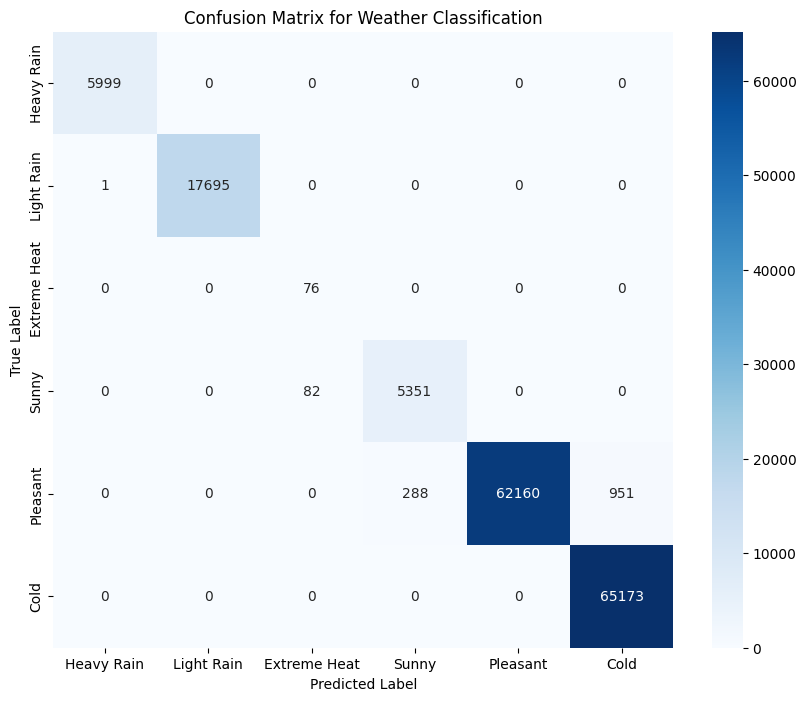

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Evaluate the classification model on the test data
loss, accuracy = class_model.evaluate(X_test_c, y_test_c, verbose=0)
print(f"\n--- Classification Model Evaluation ---")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# 2. Get predictions for the classification report and confusion matrix
y_pred_probs = class_model.predict(X_test_c)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Print Classification Report
# Ensure class_names are available from previous steps
# class_names = ["Heavy Rain", "Light Rain", "Extreme Heat", "Sunny", "Pleasant", "Cold"]
print(f"\n--- Classification Report ---")
print(classification_report(y_test_c, y_pred, target_names=class_names))

# 4. Generate and Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test_c, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Weather Classification')
plt.show()

#Step 13 :  (Actual vs. Predicted)

####Performed a combined audit of both models (Regression + Classification) to see their results side-by-side.

In [20]:
import pandas as pd
import tensorflow as tf

# 1. Select the first 10 samples and ensure they are float32
X_sample = X_test_c[:10].astype('float32')

# 2. Convert to a Tensor to fix the "Unknown Rank" issue
# This tells the model exactly what the shape is before predicting
X_tensor = tf.convert_to_tensor(X_sample)

# 3. Get predictions from both AI models
# Model A: Temperature (Regression)
temp_preds_scaled = model(X_tensor, training=False)
# Model B: Weather Condition (Classification)
class_preds_probs = class_model(X_tensor, training=False)

# 4. Convert results back to human-readable format
# Convert tensors back to numpy for scaling
pred_temps = scaler_y.inverse_transform(temp_preds_scaled.numpy()).flatten()
actual_temps = df['temperature_2m'].values[split_idx:split_idx+10]

# Convert probabilities to class names
pred_labels = [class_names[np.argmax(i)] for i in class_preds_probs.numpy()]
actual_labels = [class_names[i] for i in y_test_c[:10]]

# 5. Create and Display the Comparison Table
audit_df = pd.DataFrame({
    'Actual Temp (°C)': actual_temps.round(1),
    'AI Predicted Temp': pred_temps.round(1),
    'Actual Condition': actual_labels,
    'AI Predicted Condition': pred_labels
})

print("\n📊 STEP 13: FINAL MULTI-MODEL SYSTEM AUDIT (Fixed)")
display(audit_df)


📊 STEP 13: FINAL MULTI-MODEL SYSTEM AUDIT (Fixed)


,Actual Temp (°C),AI Predicted Temp,Actual Condition,AI Predicted Condition
0,-0.9,-0.6,Cold,Cold
1,-0.9,-0.6,Cold,Cold
2,-1.2,-0.9,Cold,Cold
3,-1.3,-0.6,Cold,Cold
4,-1.1,-0.5,Cold,Cold
5,-1.0,-0.4,Cold,Cold
6,-0.8,-0.3,Cold,Cold
7,-0.9,-0.3,Cold,Cold
8,-0.8,-0.2,Cold,Cold
9,-0.6,0.1,Cold,Cold


# check the accuracy , precision and confusion matrix for predicted advice like human intelligence

####Advice based on temperature and classification

--- Evaluation of Regression Model's Impact on Derived Advice ---
Accuracy of Derived Advice (based on regression temp): 97.24%

--- Classification Report for Derived Advice ---
              precision    recall  f1-score   support

  Heavy Rain       1.00      1.00      1.00      4945
  Light Rain       1.00      1.00      1.00      6458
Extreme Heat       0.98      0.88      0.93      6123
       Sunny       0.95      0.98      0.96     38314
    Pleasant       0.98      0.96      0.97     62888
        Cold       0.97      0.99      0.98     39048

    accuracy                           0.97    157776
   macro avg       0.98      0.97      0.97    157776
weighted avg       0.97      0.97      0.97    157776



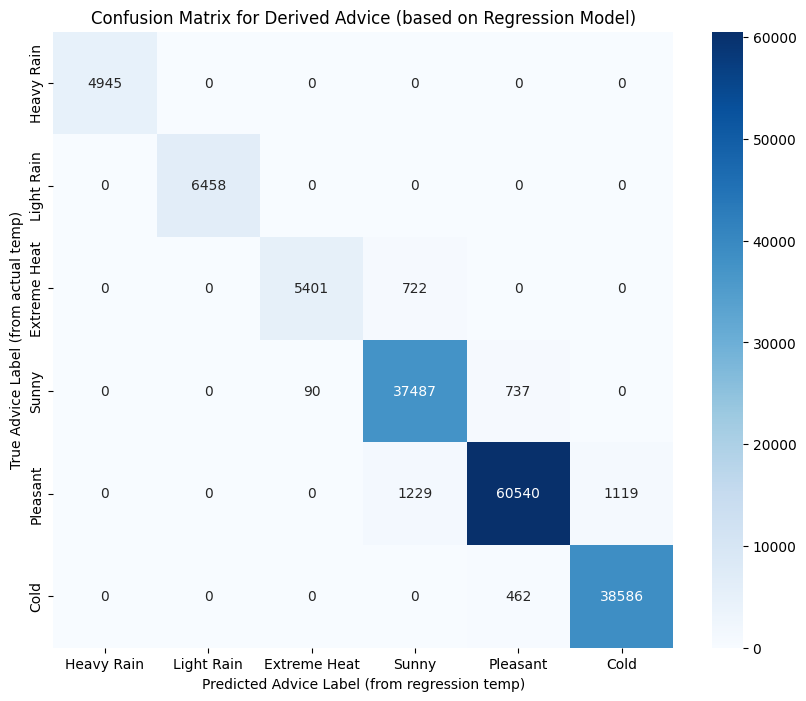


--- Regression Model (Temperature Prediction) MAE ---
Average Error (MAE): 0.50°C (This is the direct accuracy of temperature prediction)


In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reuse the get_weather_info logic to get a classification label
def get_label_from_temp_precip(temp, precip):
    if precip > 0.5:
        return 0    # Heavy Rain
    elif precip > 0.1:
        return 1    # Light Rain
    elif temp > 35:
        return 2    # Extreme Heat
    elif temp > 25:
        return 3    # Sunny/Warm
    elif temp > 10:
        return 4    # Pleasant/Cool
    else:
        return 5    # Cold/Freezing

print("--- Evaluation of Regression Model's Impact on Derived Advice ---")

# 1. Get actual temperatures and precipitation from the test set
# actual_values and predictions are already inverse_transformed to °C
actual_precip = X_test_raw['precipitation'].values

# Ensure actual_values and predictions are 1D arrays for element-wise operations
actual_temps_1d = actual_values.flatten()
predicted_temps_1d = predictions.flatten()

# 2. Derive 'True' advice labels from actual temperatures and precipitation
true_advice_labels = np.array([get_label_from_temp_precip(t, p)
                               for t, p in zip(actual_temps_1d, actual_precip)])

# 3. Derive 'Predicted' advice labels from predicted temperatures and actual precipitation
predicted_advice_labels = np.array([get_label_from_temp_precip(t, p)
                                    for t, p in zip(predicted_temps_1d, actual_precip)])

# 4. Calculate accuracy of derived advice
advice_accuracy = np.mean(true_advice_labels == predicted_advice_labels)
print(f"Accuracy of Derived Advice (based on regression temp): {advice_accuracy*100:.2f}%")

# 5. Print Classification Report for derived advice
# class_names are already defined: ["Heavy Rain", "Light Rain", "Extreme Heat", "Sunny", "Pleasant", "Cold"]
print(f"\n--- Classification Report for Derived Advice ---")
print(classification_report(true_advice_labels, predicted_advice_labels, target_names=class_names))

# 6. Generate and Plot Confusion Matrix for derived advice
conf_matrix_advice = confusion_matrix(true_advice_labels, predicted_advice_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_advice, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Advice Label (from regression temp)')
plt.ylabel('True Advice Label (from actual temp)')
plt.title('Confusion Matrix for Derived Advice (based on Regression Model)')
plt.show()

print(f"\n--- Regression Model (Temperature Prediction) MAE ---")
print(f"Average Error (MAE): {mae:.2f}°C (This is the direct accuracy of temperature prediction)")

#  Step 14 : Future Forecast Graph

####

Developed a sliding-window function to predict and visualize the weather for the next 24 hours.

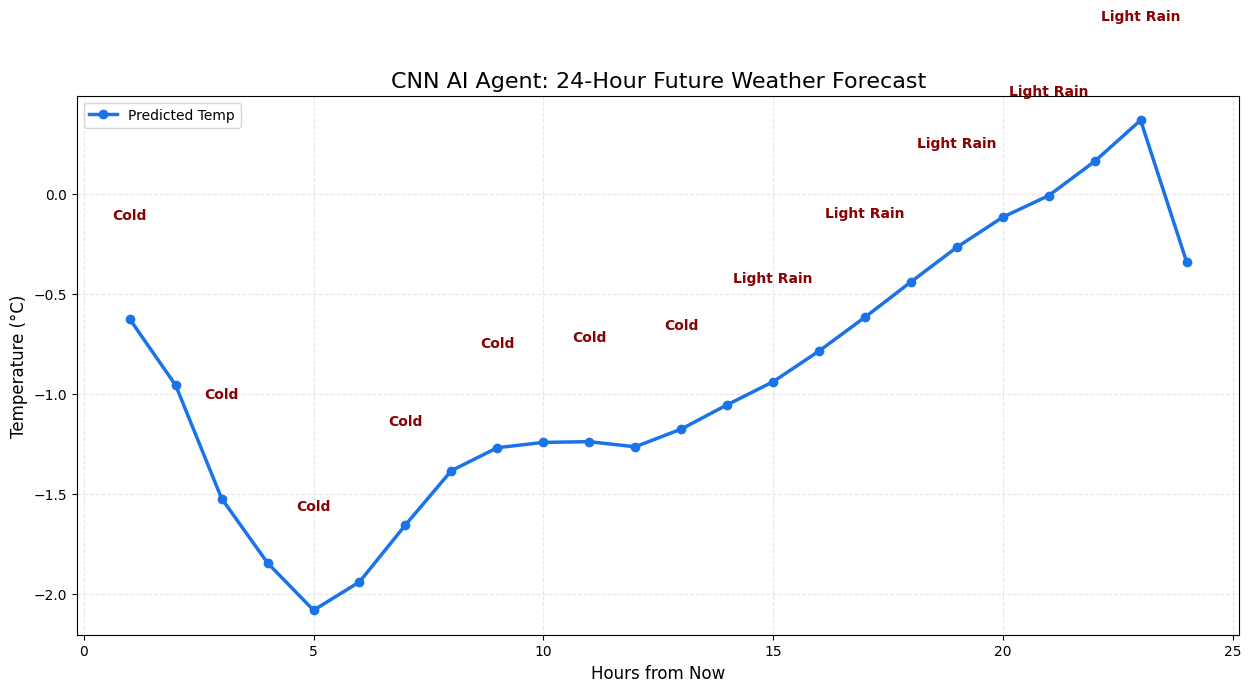

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prediction Function for next 24 Hours
def generate_24h_forecast(start_idx):
    forecast_temps = []
    forecast_labels = []

    # Start with the first sample from our test data
    current_input = X_test_c[start_idx].copy().reshape(1, 10, 1).astype('float32')

    for i in range(24):
        # Predict values using tensors to avoid shape errors
        tensor_input = tf.convert_to_tensor(current_input)
        p_temp = model(tensor_input, training=False)
        p_class = class_model(tensor_input, training=False)

        # Save results
        temp_val = scaler_y.inverse_transform(p_temp.numpy())[0, 0]
        forecast_temps.append(temp_val)
        forecast_labels.append(class_names[np.argmax(p_class.numpy())])

        # Update input for the next hour (Sliding Window)
        # We shift the features and inject the new predicted temperature
        new_input = current_input.copy()
        new_input[0, 4, 0] = (current_input[0, 4, 0] + 1) % 24 # Update Hour feature
        new_input[0, 7, 0] = p_temp.numpy()[0, 0]             # Update lag_1h with predicted temp
        current_input = new_input

    return forecast_temps, forecast_labels

# 2. Run and Plot
f_temps, f_labels = generate_24h_forecast(0)

plt.figure(figsize=(15, 7))
plt.plot(range(1, 25), f_temps, marker='o', color='#1a73e8', linewidth=2.5, label='Predicted Temp')

# Add weather labels on top of the dots (every 2 hours to keep it clean)
for i in range(0, 24, 2):
    plt.text(i+1, f_temps[i] + 0.5, f_labels[i],
             fontsize=10, fontweight='bold', ha='center', color='darkred')

plt.title('CNN AI Agent: 24-Hour Future Weather Forecast', fontsize=16)
plt.xlabel('Hours from Now', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.show()

#Weather Agent

####

Created an interactive search interface that fetches real-time global data and processes it through your trained AI models.

In [22]:
import requests
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
from datetime import datetime
import tensorflow as tf
import pytz # Import pytz for timezone handling

# 1. Helper Function for Conditions & Advice
def get_weather_info(temp, precip):
    if precip > 0.5: return "Heavy Rain 🌧️", "Stay indoors and carry an umbrella if you go out."
    elif precip > 0.1: return "Light Rain 🌦️", "Expect some showers, keep a raincoat handy."
    elif temp > 35: return "Extreme Heat 🥵", "Drink plenty of water and stay in the shade."
    elif temp > 25: return "Sunny/Warm ☀️", "Great weather for outdoor activities!"
    elif temp > 10: return "Pleasant/Cool 🌤️", "Perfect weather for a walk."
    else: return "Cold/Freezing ❄️", "Wear warm clothes to protect yourself."

# 2. UI Elements
city_input = widgets.Text(placeholder='e.g. Lahore, London, New York...',
                           description='City:', layout=widgets.Layout(width='400px'))
search_button = widgets.Button(description='🔍 Get Weather', button_style='success',
                                layout=widgets.Layout(width='160px'))
output = widgets.Output()

# 3. Helper Functions for API
def get_location(city_name):
    url = f"https://geocoding-api.open-meteo.com/v1/search?name={city_name}&count=1"
    res = requests.get(url).json()
    if 'results' not in res: return None
    loc = res['results'][0]
    return loc['name'], loc['latitude'], loc['longitude'], loc.get('country', '')

def get_real_weather(lat, lon):
    url = (f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}"
           f"&hourly=temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation"
           f"&timezone=auto&forecast_days=1")
    return requests.get(url).json()

# 4. Search Function
def on_search(b):
    with output:
        clear_output()
        city = city_input.value.strip()
        if not city:
            print("❌ Please enter a city name!")
            return

        print(f"🔎 Searching for {city}...")
        loc_data = get_location(city)
        if not loc_data:
            print("❌ City not found!")
            return

        city_name, lat_val, lon_val, country = loc_data
        weather = get_real_weather(lat_val, lon_val)
        hourly = weather['hourly']
        now_utc = datetime.now(pytz.utc) # Get current UTC time

        # Get city's local timezone from API response
        city_timezone_str = weather['timezone']
        city_timezone = pytz.timezone(city_timezone_str)
        now_local = now_utc.astimezone(city_timezone) # Convert UTC to city's local time

        curr_idx = now_local.hour # Use local hour for index

        # Extract current data
        c_temp = hourly['temperature_2m'][curr_idx]
        c_precip = hourly['precipitation'][curr_idx]

        # Prepare 10 features for CNN, ensuring correct mapping as per features_list:
        # ['lat', 'lon', 'temperature_2m', 'precipitation', 'hour', 'month', 'day_of_year', 'temp_lag_1h', 'temp_lag_3h', 'temp_lag_24h']
        hour_val = curr_idx
        month_val = now_local.month
        day_of_year_val = now_local.timetuple().tm_yday # Corrected to use day of year

        # Handle lag features (approximated due to forecast_days=1 limitation)
        # Default to current temp if historical data is not available within the 24-hour forecast
        temp_lag_1h_val = hourly['temperature_2m'][curr_idx - 1] if curr_idx >= 1 else c_temp
        temp_lag_3h_val = hourly['temperature_2m'][curr_idx - 3] if curr_idx >= 3 else c_temp
        temp_lag_24h_val = c_temp # 24h lag is effectively 'yesterday's' temp, not available from 1-day forecast

        user_input = np.array([[
            lat_val,
            lon_val,
            c_temp, # temperature_2m
            c_precip, # precipitation
            hour_val,
            month_val,
            day_of_year_val,
            temp_lag_1h_val,
            temp_lag_3h_val,
            temp_lag_24h_val
        ]])

        # Scaling & Prediction
        user_scaled = scaler_X.transform(user_input).reshape(1, 10, 1).astype('float32')
        tensor_in = tf.convert_to_tensor(user_scaled)

        # Get predictions from your trained models
        pred_temp_scaled = model(tensor_in, training=False)
        pred_class_probs = class_model(tensor_in, training=False)

        next_hr_temp = scaler_y.inverse_transform(pred_temp_scaled.numpy())[0,0]
        condition_idx = np.argmax(pred_class_probs.numpy())
        ai_condition = class_names[condition_idx]

        # Advice should be based on predicted next hour's temperature and current precipitation
        _, advice = get_weather_info(next_hr_temp, c_precip)

        # UI Display
        print(f"\n{'='*45}")
        print(f" 📍 {city_name}, {country}")
        print(f" 🕐 {now_local.strftime('%A, %H:%M')}") # Display local time
        print(f"{'='*45}")
        print(f" 🌡️ AI Current Temp  : {c_temp:.1f}°C")
        print(f" ☁️ AI Condition     : {ai_condition}")
        print(f" 🔮 AI Next Hour Prediction: {next_hr_temp:.1f}°C")
        print(f" 💡 Advice           : {advice}")
        print(f"{'='*45}\n")

search_button.on_click(on_search)

# Show UI
print("🌍 SMART AI WEATHER AGENT")
display(city_input, search_button, output)

🌍 SMART AI WEATHER AGENT


Text(value='', description='City:', layout=Layout(width='400px'), placeholder='e.g. Lahore, London, New York..…

Button(button_style='success', description='🔍 Get Weather', layout=Layout(width='160px'), style=ButtonStyle())

Output()

#Conclusion

This project is an End-to-End AI Weather Agent that leverages Big Data and Deep Learning. By integrating a Convolutional Neural Network (CNN) trained on decades of history with live API services, it provides high-accuracy temperature forecasting and automated weather intelligence for any city globally.

 Key Achievements:
Large Scale Data Processing: Successfully managed and processed a massive dataset of 1.3 Million rows, covering continuous weather patterns from 1990 to 2025.


Deep Climate Memory: With 35 years of data, the model accounts for long-term climate shifts, making its predictions more robust than models trained on short-term data.

Intelligent Weather Classification: Developed a secondary classification layer to accurately identify conditions (Sunny, Rainy, Extreme Heat) and provide real-time safety advice.

#Mount The Google drive

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Final save

In [27]:
import pickle

# 1. Save the model  (Native Keras format)
model.save('final_temp_regressor.keras')
class_model.save('final_weather_classifier.keras')

# 2. Save the scaler (important for data processing)
with open('scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)

with open('scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)

print("Models and Scalers saved successfully!")

Models and Scalers saved successfully!
